# 1 · Causal vs predictive control under confounding

**The one result that motivates `chc`.** Most data science stops at *prediction*. But a decision
*changes the future*, so it must be judged as an **intervention**, not a correlation — and chosen by
**optimal control**, not by argmax over a predictive score.

Here we take a confounded offline log (the historical action was targeted at exactly the customers
most likely to churn), fit the action's effect two ways, and control the *true* system with each.
The predictive controller drives the system off a cliff; the causal one matches the oracle.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc.benchmark import PricingTask, leaderboard
from chc.causal import ConfoundedLinearSystem, estimate_control_effect
from chc.flagship import run_flagship

## The confounded log

The data-generating process: a covariate `z` (churn risk) drives **both** the historical action `u`
(retention teams gave big discounts to at-risk customers) **and** the outcome `x'`. That backdoor path
`u ← z → x'` is what biases a naive fit.

In [2]:
system = ConfoundedLinearSystem()
data = system.sample(20_000, jax.random.key(0))
print("columns:", list(data))
print(f"corr(u, z) = {float(jnp.corrcoef(data['u'], data['z'])[0, 1]):+.3f}  "
      "→ the action is entangled with the confounder")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


columns: ['x', 'z', 'u', 'x_next', 'w']
corr(u, z) = -0.950  → the action is entangled with the confounder


## The naive fit flips the sign

Regress the outcome on the action **without** adjusting for `z` (predictive) vs **with** the
adjustment set (causal). The true effect is `+1.0`.

In [3]:
b_true = system.b_true
b_naive = float(estimate_control_effect(data, adjust_for=()))
b_causal = float(estimate_control_effect(data, adjust_for=("z",)))

effects = pd.DataFrame(
    {"estimate": [b_true, b_causal, b_naive]},
    index=["true effect", "causal (adjust for z)", "predictive (naive)"],
)
effects

,estimate
true effect,1.000000
causal (adjust for z),0.998507
predictive (naive),-0.203464


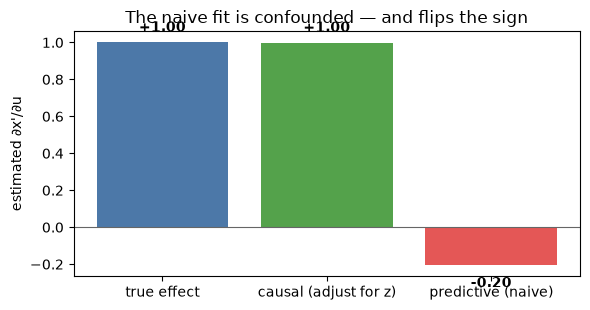

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.2))
colors = ["#4C78A8", "#54A24B", "#E45756"]
ax.bar(effects.index, effects["estimate"], color=colors)
ax.axhline(0, color="0.4", lw=0.8)
ax.set_ylabel("estimated ∂x'/∂u")
ax.set_title("The naive fit is confounded — and flips the sign")
for i, v in enumerate(effects["estimate"]):
    ax.text(i, v + (0.06 if v >= 0 else -0.12), f"{v:+.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Control the *true* system with each estimate

Each controller believes its own estimate and steers the true plant toward a target `x* = 2`. The
predictive controller thinks the action *hurts*, so it pushes the wrong way and diverges; the causal
controller reaches the target.

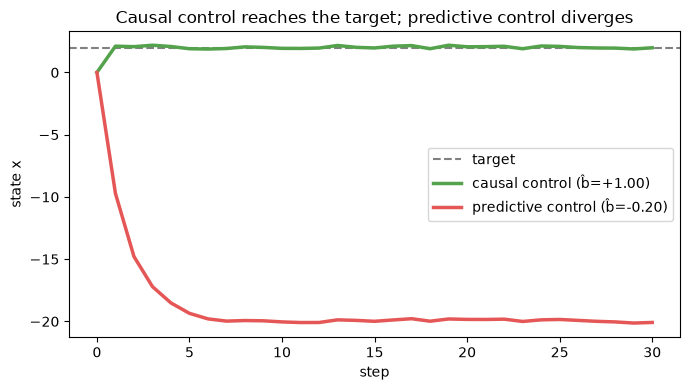

causal final state    = +1.98  (target +2)
predictive final state = -20.09  ← catastrophe


In [5]:
r = run_flagship()
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(r["x_target"], ls="--", c="0.5", label="target")
ax.plot(r["xs_causal"], lw=2.5, color="#54A24B", label=f"causal control (b̂={r['b_causal']:+.2f})")
ax.plot(r["xs_naive"], lw=2.5, color="#E45756", label=f"predictive control (b̂={r['b_naive']:+.2f})")
ax.set_xlabel("step")
ax.set_ylabel("state x")
ax.set_title("Causal control reaches the target; predictive control diverges")
ax.legend()
plt.tight_layout()
plt.show()

print(f"causal final state    = {float(r['xs_causal'][-1]):+.2f}  (target {r['x_target']:+.0f})")
print(f"predictive final state = {float(r['xs_naive'][-1]):+.2f}  ← catastrophe")

## The benchmark: regret vs an oracle

`chc` ships a benchmark of confounded / constrained / shifting tasks with *ground-truth* interventional
effects, so we can measure **regret against an oracle** (a controller that knows the true effect), plus
constraint violations and out-of-support action rate.

In [6]:
results = PricingTask().run()
board = pd.DataFrame(
    [
        {
            "controller": r.controller,
            "cost": r.cost,
            "regret": r.regret,
            "constraint_viol": r.constraint_violations,
            "ood_rate": r.ood_rate,
        }
        for r in sorted(results, key=lambda r: r.regret)
    ]
).set_index("controller")
board.round(2)

,cost,regret,constraint_viol,ood_rate
controller,,,,
oracle,4.61,0.00,0.00,0.0
causal-CHC,4.61,0.00,0.00,0.0
predictive,13736.84,13732.23,0.97,1.0


**Read it off the table:** `causal-CHC` matches the oracle (regret ≈ 0, no constraint violations, no
out-of-support actions), while `predictive` is catastrophic on *every* axis — huge regret, violates the
safe-state constraint most of the time, and acts entirely outside the logged support.

### Takeaway
Prediction ≠ decision. Under confounding, optimising control against a predictive model is not just
suboptimal — it can be actively harmful. `chc` makes the causal + control step a first-class object.